In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [6]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.shape

(10000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [13]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [14]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [15]:
df.sample()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
735,497,France,Male,47,6,0.0,1,1,1,90055.08,0


In [35]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [36]:
X = df.drop(columns=['Exited'])
y=df['Exited']

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)


In [38]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
4656,843,38,8,134887.53,1,1,1,10804.04,False,False,False
5896,744,30,1,128065.12,1,1,0,121525.48,False,True,True
4821,511,33,3,0.00,2,1,0,132436.71,False,False,False
3173,485,27,3,0.00,2,1,0,141449.86,False,False,False
7486,814,49,8,0.00,2,0,0,157822.54,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
5965,724,30,9,142475.87,1,1,1,107848.24,False,False,False
7639,541,46,6,0.00,2,1,1,83456.67,False,False,True
2175,757,34,9,101861.36,2,0,0,187011.96,True,False,False
2821,714,33,10,103121.33,2,1,1,49672.01,False,True,False


In [39]:
y_train

4656    0
5896    0
4821    0
3173    0
7486    0
       ..
5965    0
7639    0
2175    0
2821    0
7261    0
Name: Exited, Length: 8000, dtype: int64

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [41]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [47]:
model = Sequential()

model.add(Dense(3,activation='relu',input_dim=11))
model.add(Dense(3,activation='relu'))
model.add(Dense(1,activation='relu'))

In [48]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52 (208.00 B)

 Trainable params: 52 (208.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(loss='binary_crossentropy', optimizer='Adam')

In [51]:
hist = model.fit(X_train_scaled,y_train,epochs=30)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9942
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7556
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6675
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6198
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5847
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5405
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5183
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5008
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4865
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4739
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4587
Epoch 12/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4473
Epoch 13/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4383
Epoch 14/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4306
Epoch 15/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

In [62]:
hist.history

{'loss': [0.9941883087158203,
  0.7555602192878723,
  0.6674821376800537,
  0.6198430061340332,
  0.5846826434135437,
  0.5405212044715881,
  0.5182673335075378,
  0.5008288621902466,
  0.48646625876426697,
  0.473896324634552,
  0.4587082266807556,
  0.44730299711227417,
  0.4382501244544983,
  0.4306475818157196,
  0.4239412248134613,
  0.41868844628334045,
  0.41424572467803955,
  0.4106958210468292,
  0.4067758619785309,
  0.40470632910728455,
  0.4011516273021698,
  0.39655232429504395,
  0.3929327428340912,
  0.3904484808444977,
  0.387851357460022,
  0.3852349519729614,
  0.38271281123161316,
  0.3799457848072052,
  0.37707754969596863,
  0.37413373589515686]}

In [53]:
model.layers[1].get_weights()

[array([[-0.28497553,  0.6164215 , -0.16314718],
        [-0.43082762, -0.20497662,  0.4200297 ],
        [-0.16846156, -0.7538956 , -0.24363597]], dtype=float32),
 array([ 0.        , -0.00074448,  0.06483272], dtype=float32)]

In [54]:
y_pred = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [55]:
y_log = np.where(y_pred>0.5,1,0)

In [56]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_log)

0.8395

In [57]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])


In [63]:
hist =model.fit(X_train_scaled,y_train,epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8623 - loss: 0.3432 - val_accuracy: 0.8581 - val_loss: 0.3384
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8630 - loss: 0.3425 - val_accuracy: 0.8581 - val_loss: 0.3408
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8634 - loss: 0.3436 - val_accuracy: 0.8587 - val_loss: 0.3414
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8639 - loss: 0.3421 - val_accuracy: 0.8544 - val_loss: 0.3422
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8630 - loss: 0.3436 - val_accuracy: 0.8556 - val_loss: 0.3380
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8642 - loss: 0.3435 - val_accuracy: 0.8556 - val_loss: 0.3370
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8630 - loss: 0.3429 - val_accuracy: 0.8556 - val_loss: 0.3383
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8656 - loss: 0.3423 - val_accu

In [59]:
import matplotlib.pyplot as plt

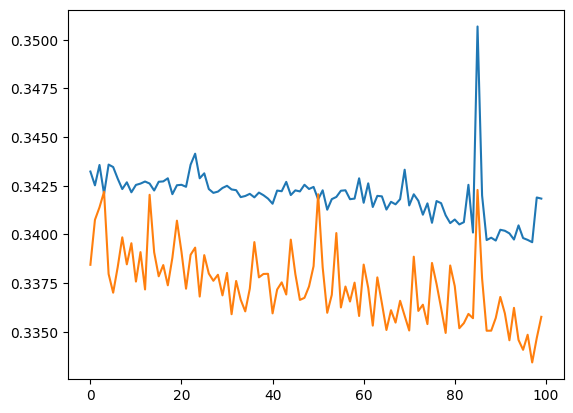

In [64]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

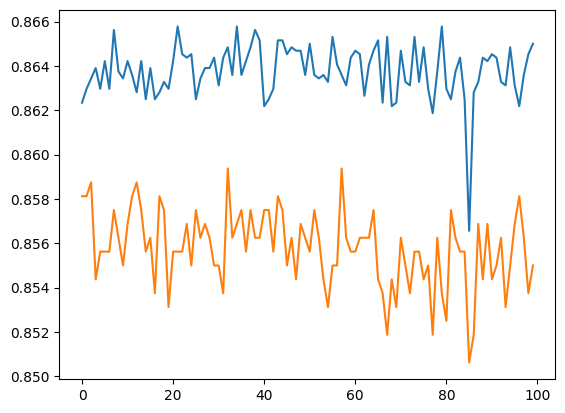

In [65]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])